In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..") / "src"))

In [ ]:
import json
from run_fit import run

project_root = Path("..").resolve()
session_config_path = project_root / "data" / "session_config.json"

with open(session_config_path, "r", encoding="utf-8") as f:
    session_config = json.load(f)

n_components = int(session_config["n_components"])
config_path = session_config["config_path"]

print("Selected number of components:", n_components)
print("Using config:", config_path)


x_final, summary = run(config_path, n_components=n_components)

# Fit summary

{'run_timestamp': '2026-04-13 12:42:58',
 'config_path': '/Users/marcotamburi/projects/uni_project/svd_project/configs/fit4_config.json',
 'n_components': 4,
 'stage1_success': True,
 'stage1_cost': 0.03473082453057359,
 'stage2_success': True,
 'stage2_cost': 0.033728395715948906,
 'T_shape': [41],
 'V_prime_shape': [4, 41],
 'U_prime_shape': [221, 4],
 'spectral_matrix_shape': [221, 41],
 'wavelengths_shape': [221],
 'preprocess_coeffs': {'C11': -0.22421885840014721,
  'C21': -0.08956113530675792,
  'C31': 0.17727217073507556,
  'C41': 0.229847036542434,
  'C14': -0.024022737585642467,
  'C24': 0.15491275850998878,
  'C34': 0.2998956407067972,
  'C44': -0.28333291843624775},
 'output_dir': '../results/fit4_run/fit4_2026-04-13_12-42-58',
 'final_params': {'Tm1': 336.60343884395655,
  'Tm2': 331.37679769973056,
  'Tm3': 352.4066775206057,
  'dH1': -16959.54075882302,
  'dH2': -33005.60898866964,
  'dH3': -33607.41386824198,
  'C11': -0.2216698924929153,
  'C12': -0.23707705322838396,
 

## Output directory

../results/fit4_run/fit4_2026-04-13_12-42-58


## Preprocessing - folded spectrum

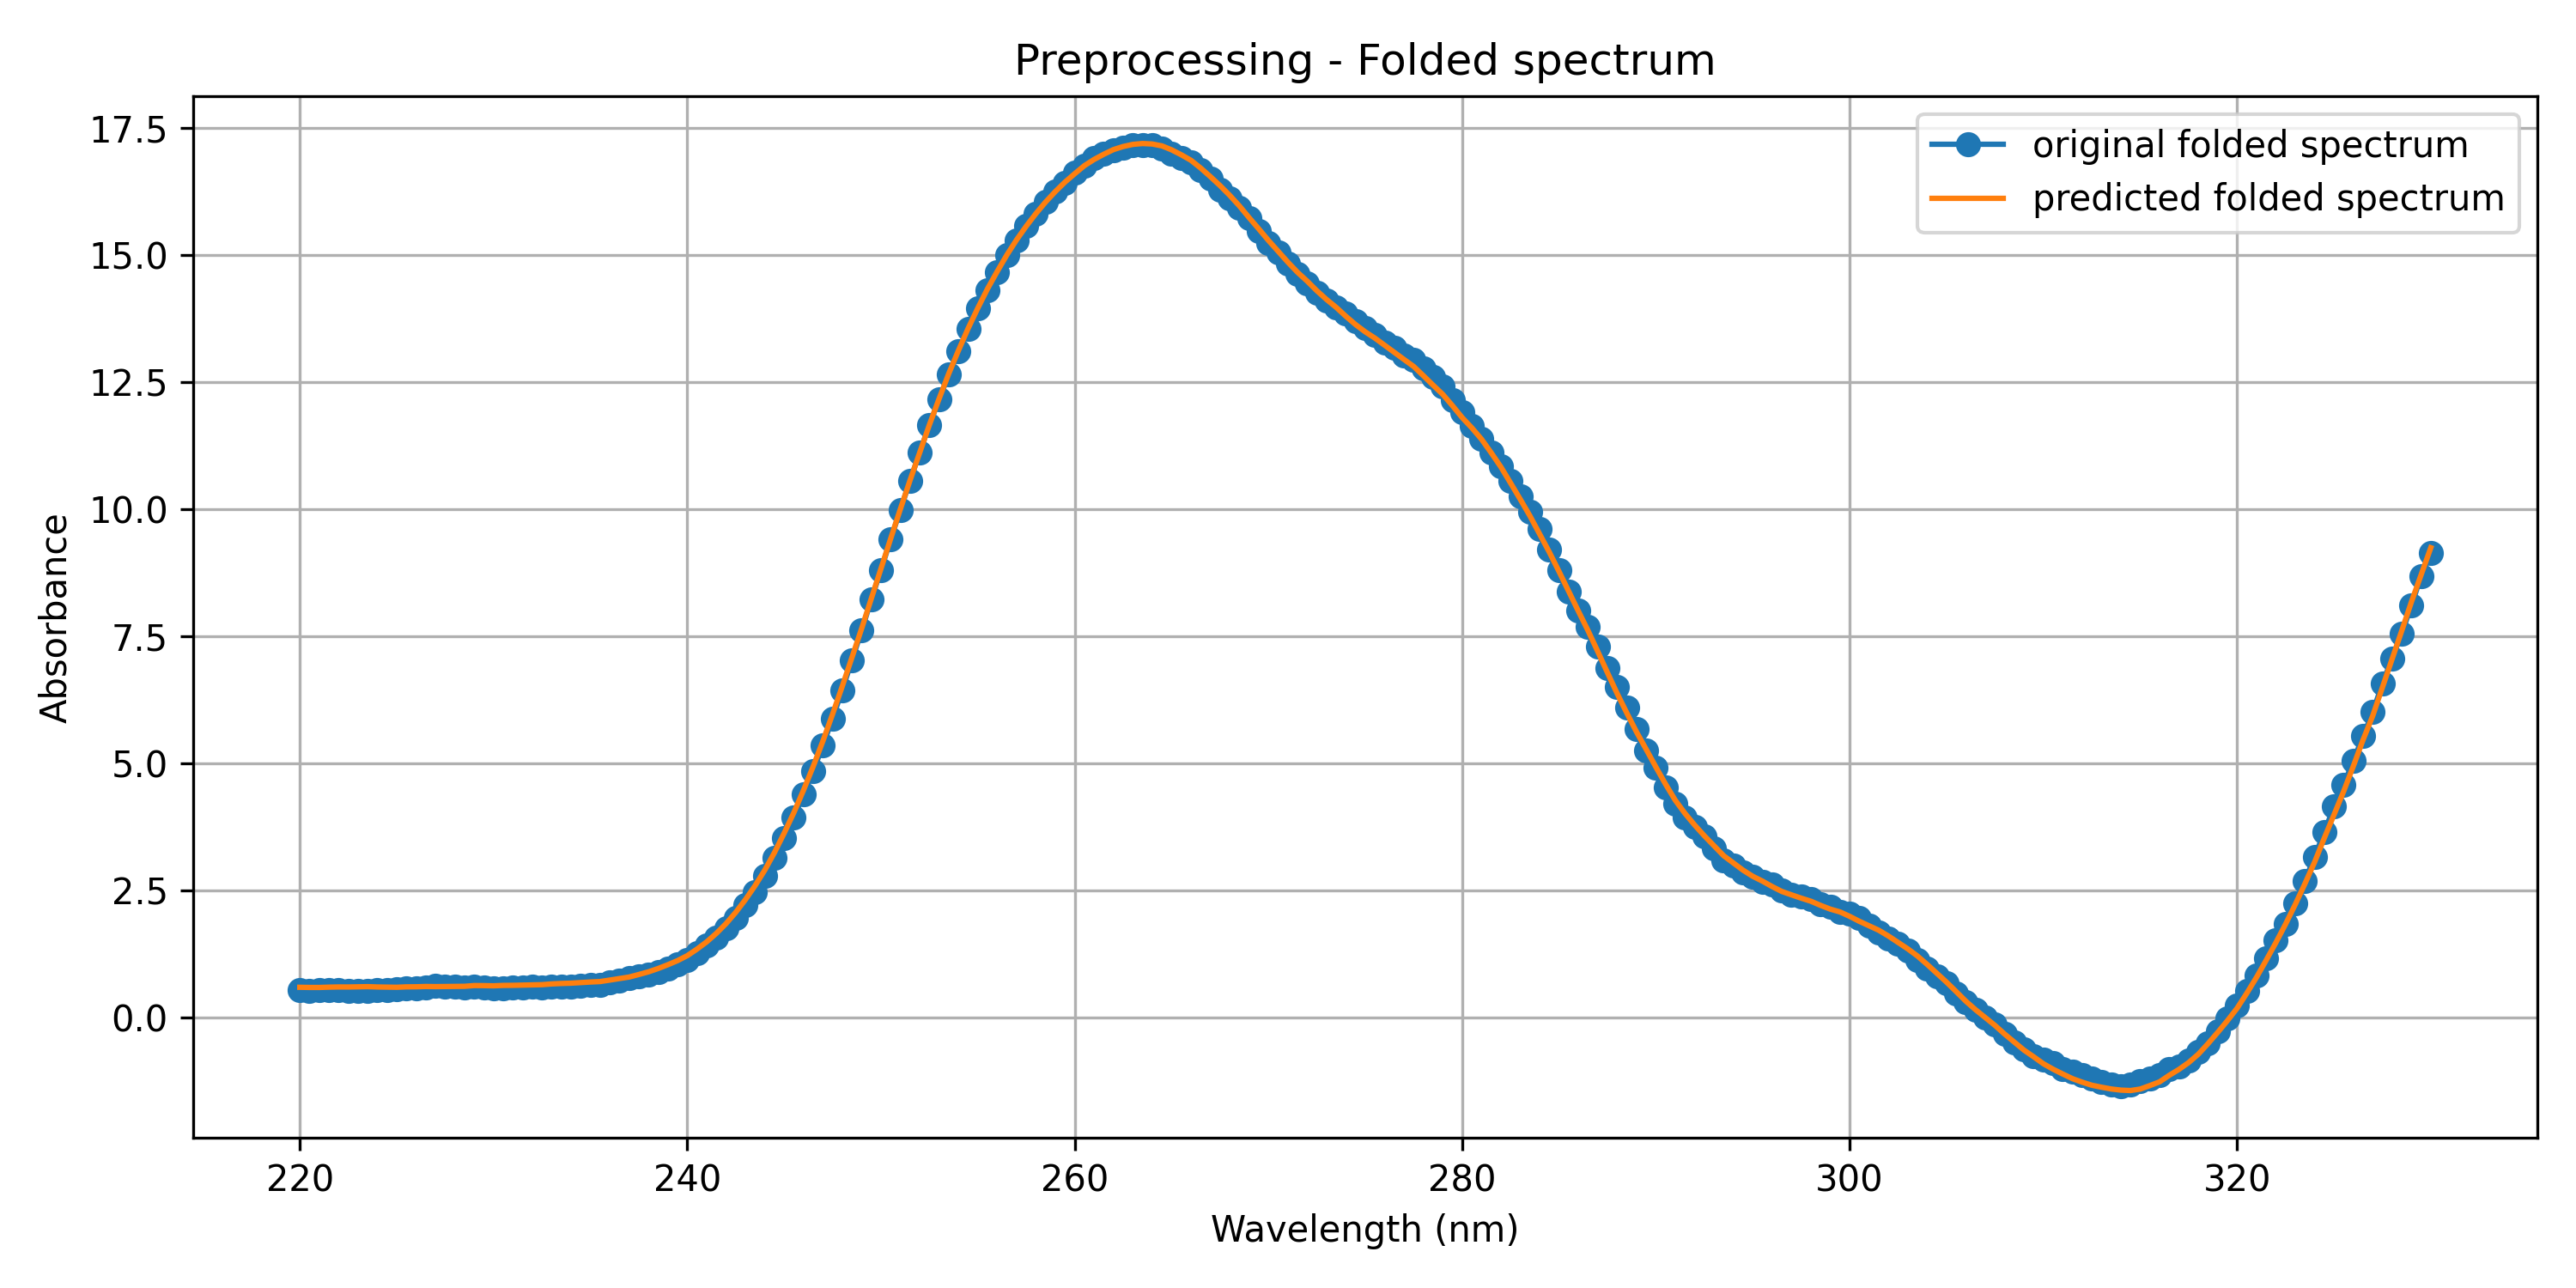

## Preprocessing - unfolded spectrum

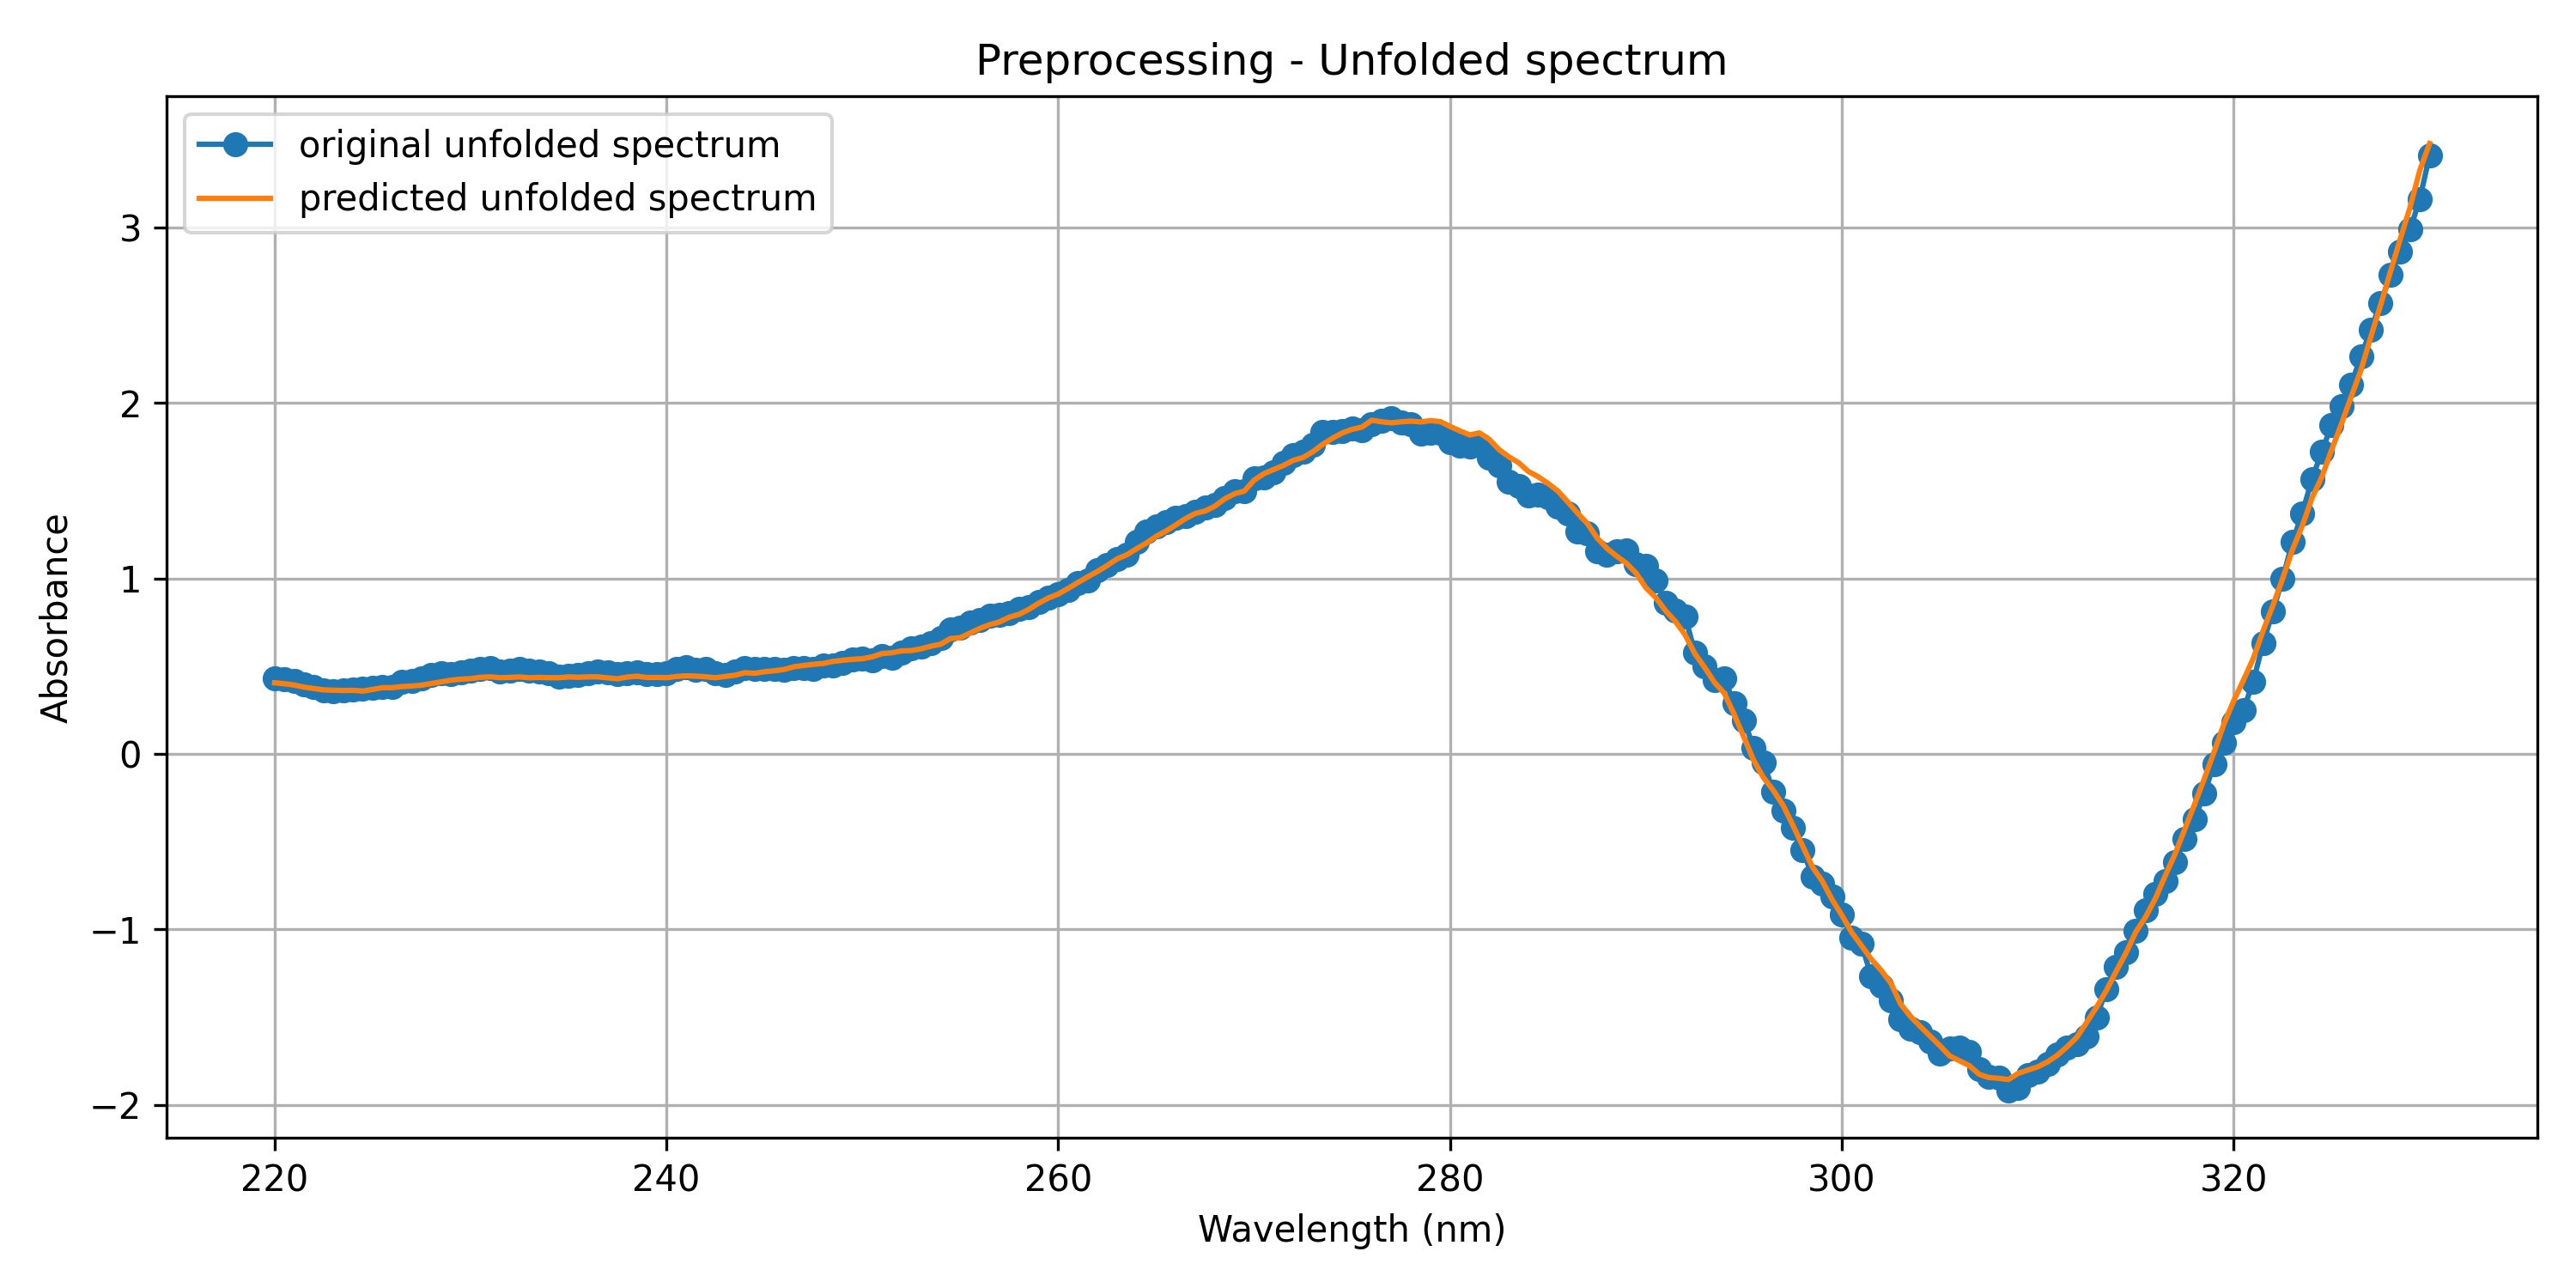

## Stage 1 global fit

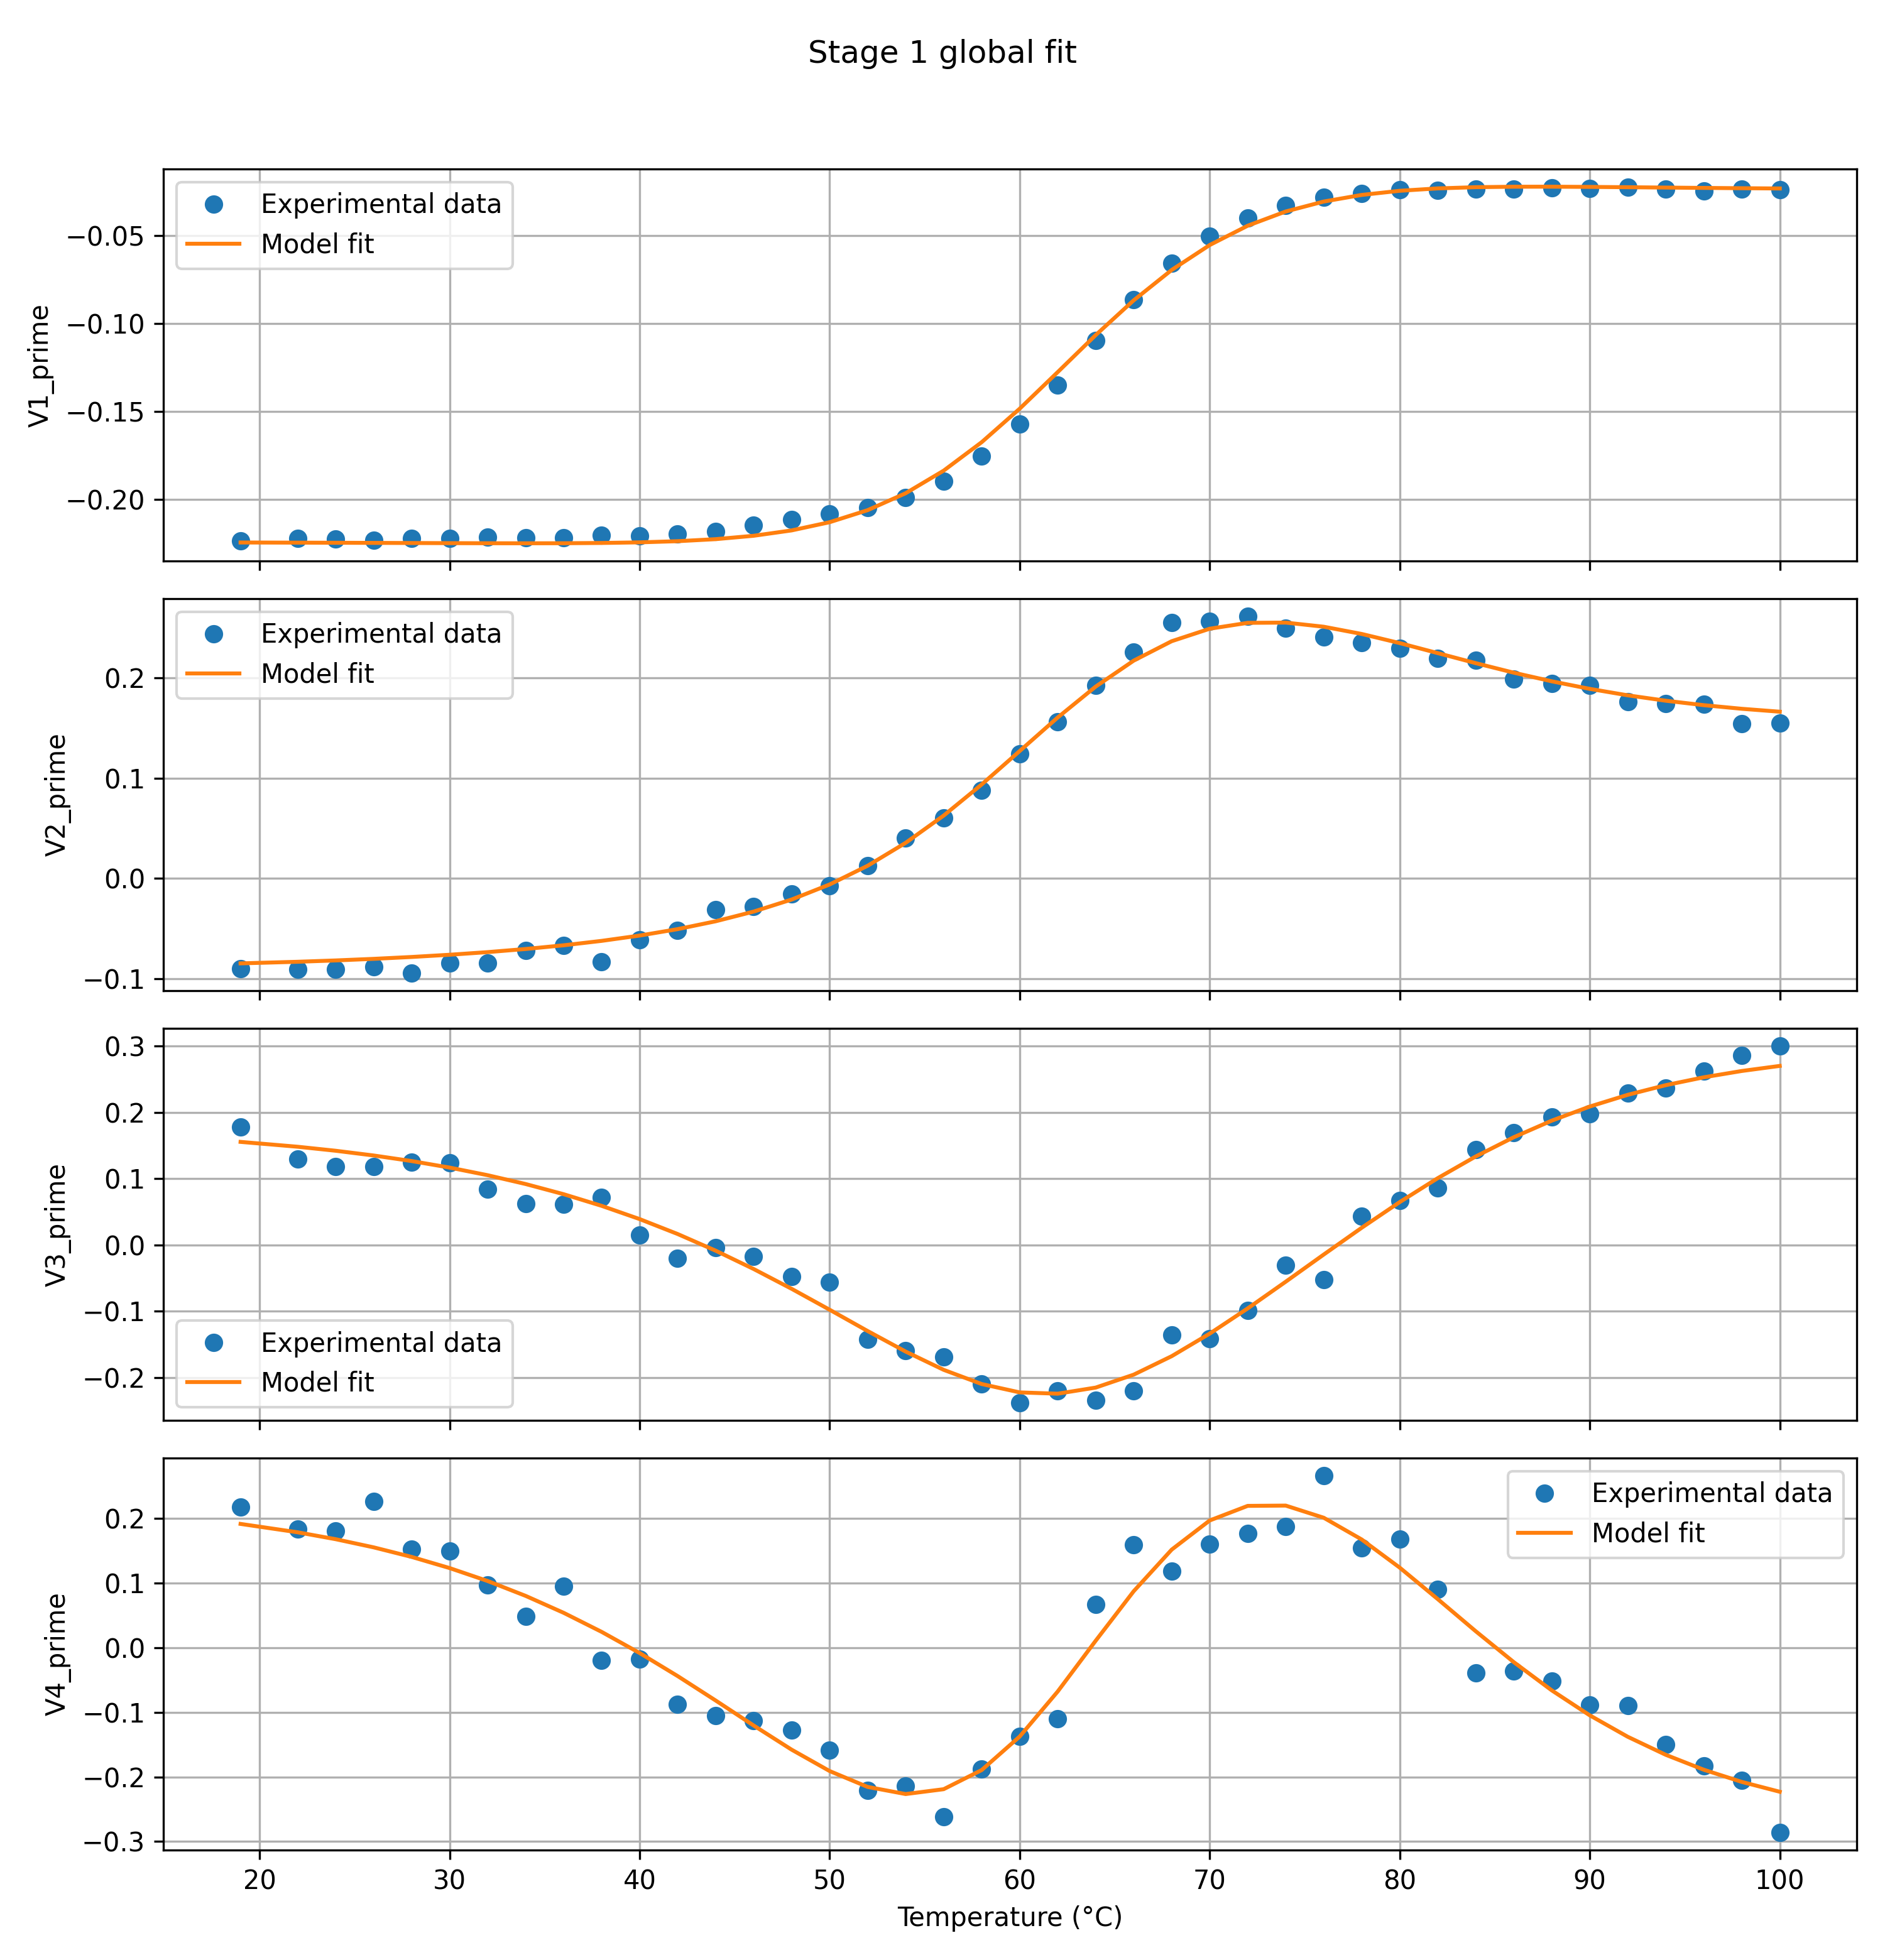

## Final global fit

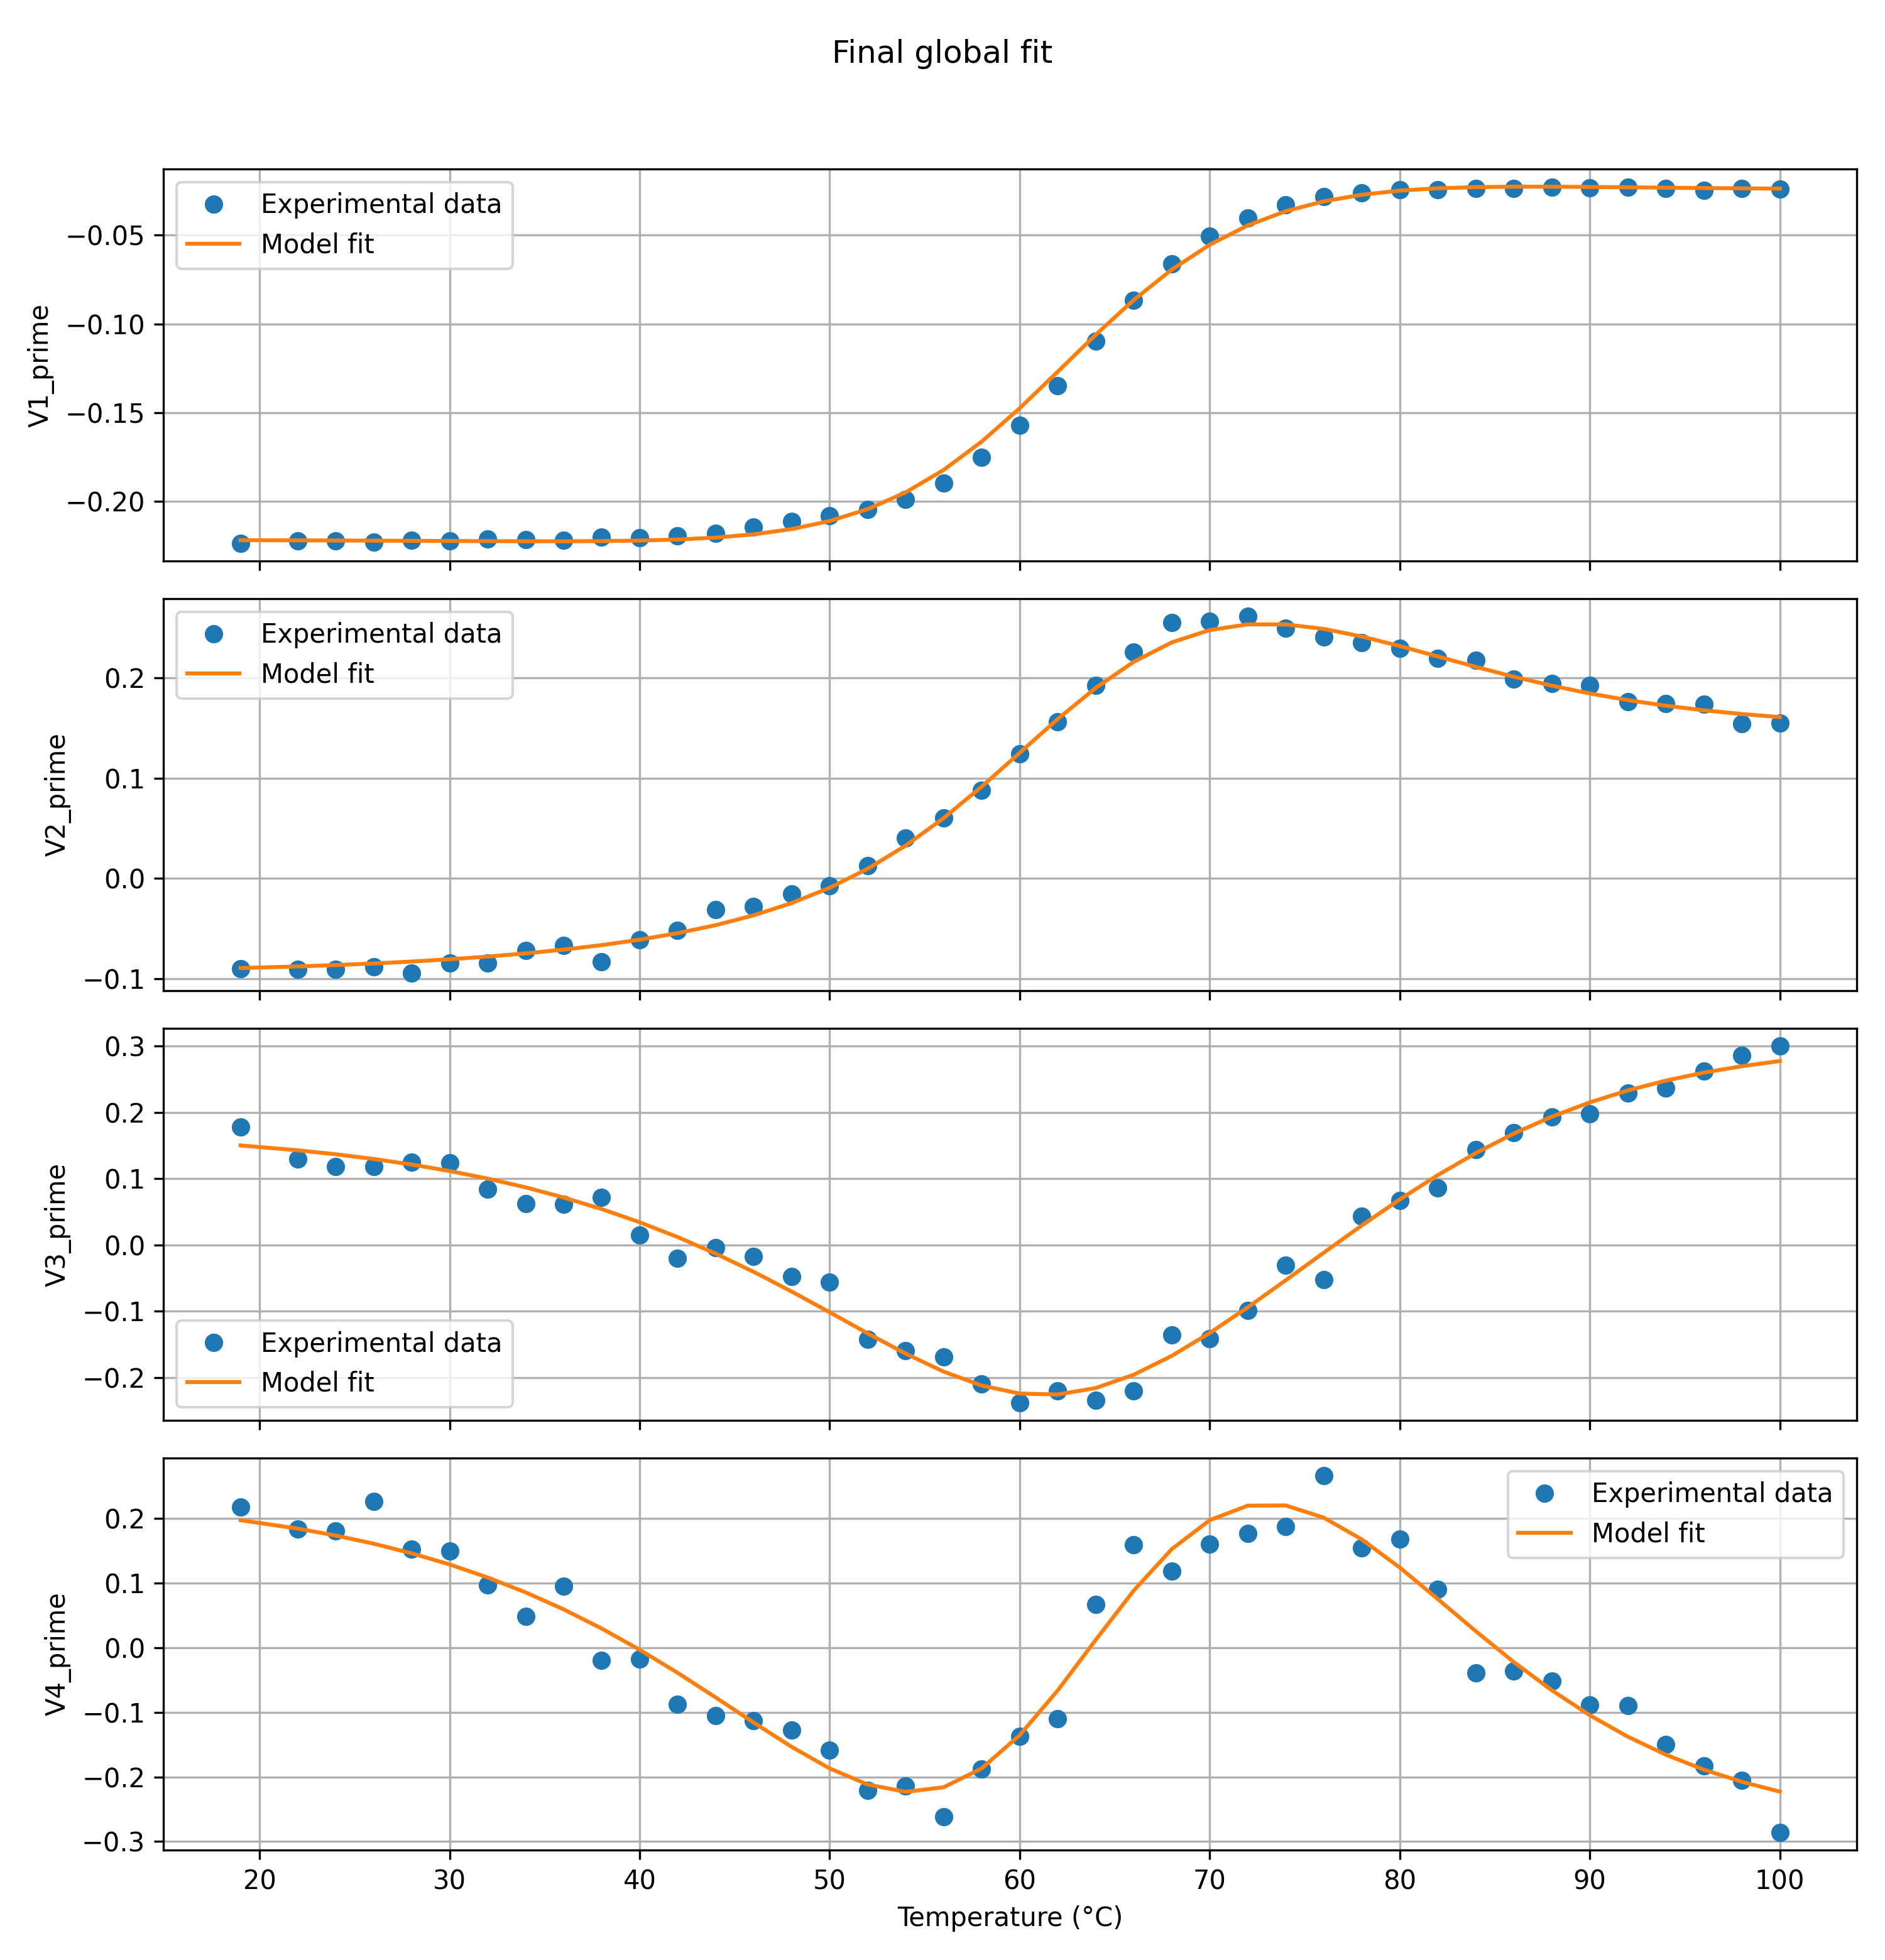

## Final parameters

,name,value,vary,lower,upper,stage,note
0,Tm1,336.603439,1,293,340,1,thermo stage1
1,Tm2,331.376798,1,300,360,1,thermo stage1
2,Tm3,352.406678,1,305,380,1,thermo stage1
3,dH1,-16959.540759,1,-50000,-1000,1,thermo stage1
4,dH2,-33005.608989,1,-50000,-1000,1,thermo stage1
5,dH3,-33607.413868,1,-50000,-1000,1,thermo stage1
6,C11,-0.221670,1,-10,10,2,init from preprocessing and refit in stage2
7,C12,-0.237077,1,-10,10,1,fit in stage1
8,C13,-0.012971,1,-10,10,1,fit in stage1
9,C14,-0.024421,1,-10,10,2,init from preprocessing and refit in stage2


In [3]:
from pathlib import Path
from IPython.display import Image, display, Markdown
import pandas as pd

out_dir = Path(summary["output_dir"])

display(Markdown("# Fit summary"))
display(summary)

display(Markdown("## Output directory"))
print(out_dir)

plot_files = [
    ("Preprocessing - folded spectrum", out_dir / "preprocess_folded_fit.png"),
    ("Preprocessing - unfolded spectrum", out_dir / "preprocess_unfolded_fit.png"),
    ("Stage 1 global fit", out_dir / "stage1_global_fit.png"),
    ("Final global fit", out_dir / "final_global_fit.png"),
]

for title, plot_path in plot_files:
    display(Markdown(f"## {title}"))
    if plot_path.exists():
        display(Image(filename=str(plot_path)))
    else:
        print(f"File non trovato: {plot_path.name}")

params_final_path = out_dir / "params_final.csv"
if params_final_path.exists():
    display(Markdown("## Final parameters"))
    display(pd.read_csv(params_final_path))
else:
    display(Markdown("## Final parameters"))
    print("File params_final.csv non trovato.")

In [4]:
import pandas as pd
from pathlib import Path

out_dir = Path(summary["output_dir"])

df_stage1 = pd.read_csv(out_dir / "stage1_fit_curves.csv")
df_final = pd.read_csv(out_dir / "final_fit_curves.csv")

df_stage1.head(), df_final.head()

(   T_kelvin  T_celsius    V1_exp    V1_fit  V1_resid    V2_exp    V2_fit  \
 0    292.15       19.0 -0.223733 -0.224479  0.000746 -0.089938 -0.084830   
 1    295.15       22.0 -0.222227 -0.224562  0.002334 -0.090482 -0.083228   
 2    297.15       24.0 -0.222392 -0.224626  0.002234 -0.090960 -0.081899   
 3    299.15       26.0 -0.223066 -0.224696  0.001631 -0.088463 -0.080319   
 4    301.15       28.0 -0.222065 -0.224771  0.002706 -0.094412 -0.078445   
 
    V2_resid    V3_exp    V3_fit  V3_resid    V4_exp    V4_fit  V4_resid  
 0 -0.005109  0.178291  0.155554  0.022737  0.217097  0.191311  0.025785  
 1 -0.007254  0.130111  0.148245 -0.018134  0.182933  0.178368  0.004564  
 2 -0.009061  0.118297  0.142206 -0.023909  0.180471  0.167692  0.012778  
 3 -0.008143  0.118222  0.135065 -0.016842  0.226097  0.155091  0.071006  
 4 -0.015968  0.124559  0.126657 -0.002098  0.152660  0.140298  0.012362  ,
    T_kelvin  T_celsius    V1_exp    V1_fit  V1_resid    V2_exp    V2_fit  \
 0    29